In [ ]:
import numpy as np
import pandas as pd

# Import visualization packages
import matplotlib.pyplot as plt

# Import relevant ML packages
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve
import shap

## Refining the Initial Model

The initial model identified Practice/Facility Size as having the highest feature importance. Subsequent investigation shows that missing facility-size information was strongly associated with default decisions. This raised the question of whether the feature was capturing a characteristic of default disputes rather than a general predictor of arbitration outcomes. This notebook therefore excludes default decisions and examines whether the predictive structure changes among non-default disputes. In other words, we are analyzing disputes where both parties are present in the negotiations.

### 1. Loading and Initial Cleaning of the Data

Load the IDR data and prepare the fields for modeling by cleaning values, standardizing data types, and removing unsuitable predictors.

In [5]:
# This is our target variable.
target_column = "Offer Selected from Provider or Issuer"

# Drop columns that will not be used as predictors, including identifiers,
# descriptive fields, and fields excluded from the analytical dataset.
columns_to_drop = [ "QPA as Percent of Median QPA",
                    "Provider/Facility Offer as Percent of Median Provider/Facility Offer Amount",
                    "Health Plan/Issuer Offer as Percent of Median Health Plan/Issuer Offer Amount",
                    "Prevailing Offer as Percent of Median Prevailing Offer Amount",
                    "Item or Service Description",
                    "Dispute Number",
                    "DLI Number",
                    "Provider/Facility Group Name",
                    "Provider/Facility NPI Number" ]

# These are columns linked to the target outcome, and will also be dropped.
outcome_derived_columns = [ "Payment Determination Outcome",
                            "Default Decision",
                            "Provider/Facility Offer as % of QPA",
                            "Health Plan/Issuer Offer as % of QPA",
                            "Prevailing Party Offer as % of QPA" ]

float_columns = [ "Length of Time to Make Determination",
                  "IDRE Compensation",
                  "Prevailing Party Offer as % of QPA",
                  "Provider/Facility Offer as % of QPA",
                  "Health Plan/Issuer Offer as % of QPA",
                  "Quarter" ]

# Load in Independent Dispute Resolution data
dataset_path = r"C:\Users\choia\Downloads\concatenated_IDR_PUFs_2024.csv"
idr_data = pd.read_csv(dataset_path, low_memory=False)

print(f"Rows: {len(idr_data):,}")
print(f"Columns: {len(idr_data.columns)}")


# Initial data cleaning
idr_data["Quarter"] = idr_data["Quarter"].astype(str)

idr_data["Length of Time to Make Determination"] = idr_data["Length of Time to Make Determination"].astype(str)


# Replace source placeholders with missing values.
idr_data.replace( ["+", "*", "N/R"], np.nan, inplace=True )

# Remove formatting characters from percentage fields.
percentage_columns = [ "Prevailing Party Offer as % of QPA",
                       "Provider/Facility Offer as % of QPA",
                       "Health Plan/Issuer Offer as % of QPA" ]

for column in percentage_columns:
    idr_data[column] = (idr_data[column]
                        .astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace("%", "", regex=False) )

# Remove currency formatting from IDRE compensation.
idr_data["IDRE Compensation"] = (idr_data["IDRE Compensation"]
                                    .astype(str)
                                    .str.replace("$", "", regex=False)
                                    .str.replace(",", "", regex=False) )

# Convert the dataframe to categorical dtype.
idr_data = idr_data.astype("category")

# Convert designated numeric fields to float.
idr_data[float_columns] = idr_data[float_columns].astype(float)

# Retain records with non-negative prevailing-party offers.
idr_data = idr_data[idr_data["Prevailing Party Offer as % of QPA"] >= 0]

# Remove fields excluded from the analytical dataset.
idr_data = idr_data.drop( columns=columns_to_drop )

print(f"Rows after cleaning: {len(idr_data):,}")
print(f"Columns after cleaning: {len(idr_data.columns)}")

Rows: 2,172,394
Columns: 32
Rows after cleaning: 1,806,014
Columns after cleaning: 23


### 2. Removing Default Decisions to Refine Dataset

Define and verify the binary arbitration outcome used as the model target and identify variables that could directly encode the outcome.

In [6]:
refined_data = (idr_data[idr_data["Default Decision"] == "No"].copy())

print("Original number of records:", len(idr_data))
print("Refined number of records:", len(refined_data))
print("Records removed:", len(idr_data) - len(refined_data))
print("\nDefault decision distribution in refined data:")
print(refined_data["Default Decision"].value_counts(dropna=False))

Original number of records: 1806014
Refined number of records: 1397948
Records removed: 408066

Default decision distribution in refined data:
Default Decision
No     1397948
Yes          0
Name: count, dtype: int64


### 3. Target Definition
Define and verify the binary arbitration outcome for the non-default dispute population.

In [7]:
target_column = "Offer Selected from Provider or Issuer"

print("\nTarget proportions:")
print(refined_data[target_column].value_counts(normalize=True).mul(100).round(2))

# Inspect target variable before encoding

print("Target value counts:")
print(refined_data[target_column].value_counts(dropna=False))

target_data = refined_data[[target_column]].copy()

# Encode target and verify mapping
target_encoder = OrdinalEncoder()

target_encoded = target_encoder.fit_transform(target_data).ravel()

# Verify the original-to-encoded mapping.
target_check = pd.DataFrame({ "original": refined_data[target_column].astype(str),
                              "encoded": target_encoded })

print("\nOriginal and encoded target values:")
print( target_check.drop_duplicates().sort_values("encoded").to_string(index=False) )


Target proportions:
Offer Selected from Provider or Issuer
In Favor of Provider/Facility/AA Provider    85.55
In Favor of Plan/Issuer                      14.45
Name: proportion, dtype: float64
Target value counts:
Offer Selected from Provider or Issuer
In Favor of Provider/Facility/AA Provider    1196011
In Favor of Plan/Issuer                       201937
Name: count, dtype: int64

Original and encoded target values:
                                 original  encoded
                  In Favor of Plan/Issuer      0.0
In Favor of Provider/Facility/AA Provider      1.0


Among non-default disputes, 85.55% of selected outcomes were in favor of the provider/facility and 14.45% were in favor of the plan/issuer. The target encoding was verified so that 0 represents a plan/issuer win outcome and 1 represents a provider/facility win outcome.

#### 4. Feature Definition
This step is identical to the initial analysis.

In [8]:
# Remove target variables from feature dataset
feature_data = refined_data.drop( columns=[target_column, *outcome_derived_columns])

# Identify categorical features.
categorical_columns = ( feature_data
                        .select_dtypes(exclude=np.number)
                        .columns
                        .tolist() )

# Ensure categorical features use pandas categorical dtype.
for column in categorical_columns:
    feature_data[column] = ( feature_data[column].astype("category") )

print("\nNumber of features:")
print(len(feature_data.columns))

print("\nCategorical features:")
print(categorical_columns)


Number of features:
17

Categorical features:
['Type of Dispute', 'Provider/Facility Name', 'Provider Email Domain', 'Practice/Facility Size', 'Health Plan/Issuer Name', 'Health Plan/Issuer Email Domain', 'Health Plan Type', 'Dispute Line Item Type', 'Type of Service Code', 'Service Code', 'Place of Service Code', 'Location of Service', 'Practice/Facility Specialty or Type', 'Initiating Party']


### 5. Train/test split

Divide the refined dataset into training and test sets.

In [9]:
random_state = 42
test_size = 0.33

feature_train, feature_test, target_train, target_test = ( train_test_split( feature_data,
                                                                             target_encoded,
                                                                             test_size=test_size,
                                                                             random_state=random_state,
                                                                             shuffle=True ))

print("\nTraining rows:", f"{len(feature_train):,}")
print("Testing rows:", f"{len(feature_test):,}")



Training rows: 936,625
Testing rows: 461,323


### 6. 4-Fold Cross-Validation
Use stratified four-fold cross-validation to assess whether model performance is consistent across different subsets of the training data.

In [10]:
params = {  "objective": "binary:logistic",
            "eval_metric": "auc",
            "max_depth": 6,
            "learning_rate": 0.3,
            "verbosity": 0 }
# Define cross-validation

cv = StratifiedKFold(n_splits=4,
                     shuffle=True,
                     random_state=42)

cv_auc_scores = []

for fold, (train_index, validation_index) in enumerate(cv.split(feature_train, target_train), 1):

    cv_feature_train = feature_train.iloc[train_index]
    cv_feature_validation = feature_train.iloc[validation_index]

    cv_target_train = target_train[train_index]
    cv_target_validation = target_train[validation_index]

    cv_dtrain = xgb.DMatrix(data=cv_feature_train,
                            label=cv_target_train,
                            enable_categorical=True)

    cv_dvalidation = xgb.DMatrix(data=cv_feature_validation,
                                 label=cv_target_validation,
                                 enable_categorical=True)

    cv_model = xgb.train(params=params,
                         dtrain=cv_dtrain,
                         num_boost_round=175,
                         evals=[(cv_dvalidation, "validation")],
                         verbose_eval=False)

    cv_predictions = cv_model.predict(cv_dvalidation)

    cv_auc = roc_auc_score(cv_target_validation,
                           cv_predictions)

    cv_auc_scores.append(cv_auc)


print("Cross-validation AUC scores:")
print(cv_auc_scores)

print("\nMean cross-validation AUC:")
print(np.mean(cv_auc_scores))

print("\nStandard deviation of cross-validation AUC:")
print(np.std(cv_auc_scores))

Cross-validation AUC scores:
[0.8730657191159485, 0.8731452614274513, 0.8756555557359015, 0.8765632812833253]

Mean cross-validation AUC:
0.8746074543906566

Standard deviation of cross-validation AUC:
0.0015361259049078918


The refined model achieved a mean 4-fold cross-validation AUC of 0.8746 with a standard deviation of 0.0015. Performance was consistent across folds, with AUC ranging from 0.8731 to 0.8766. Although predictive perforamnce was lower than in the initial model, the results indicate that the model retains substantial predictive ability after excluding default decisions.

### 7. Refined XGBoost model

Train the refined XGBoost classifier on non-default disputes using the established model specification.

In [11]:
# Create XGBoost data matrices
dtrain = xgb.DMatrix(data=feature_train,
                     label=target_train,
                     enable_categorical=True)

dtest = xgb.DMatrix(data=feature_test,
                    label=target_test,
                    enable_categorical=True)

# Trained refined model
params = {  "objective": "binary:logistic",
            "eval_metric": "auc",
            "max_depth": 6,
            "learning_rate": 0.3,
            "verbosity": 0 }

refined_model = xgb.train(params=params,
                          dtrain=dtrain,
                          num_boost_round=175,
                          verbose_eval=False)

### 8. Model Performance with ROC-AUC and PR-AUC

Evaluate the refined model using ROC-AUC and PR-AUC to assess overall predictive performance and performance on the less-common plan/issuer outcome.


Plan/issuer outcome prevalence:
0.14304727923819102
Refined model test ROC AUC:
0.8817789547941066

Refined model provider/facility PR AUC:
0.9754788905464948

Refined model plan/issuer PR AUC:
0.6339692386372994


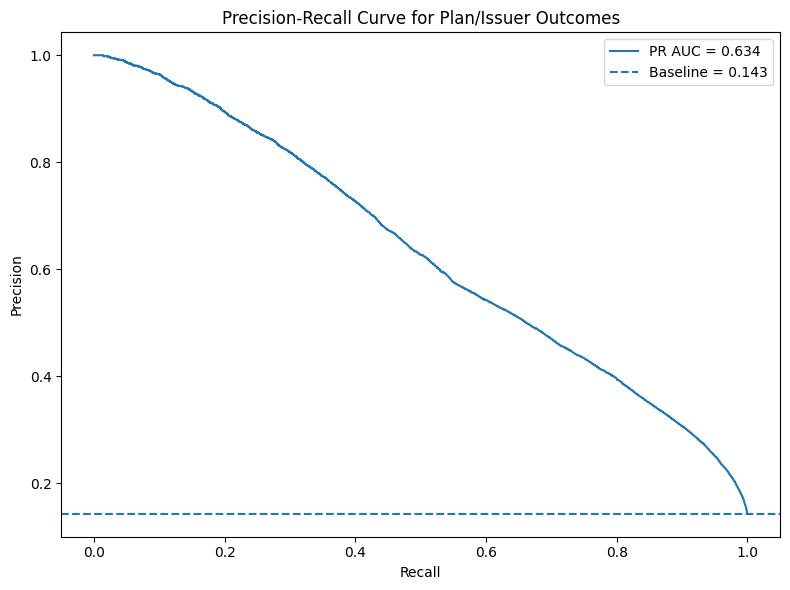

In [17]:
refined_predictions = refined_model.predict(dtest)

refined_test_auc = roc_auc_score(
    target_test,
    refined_predictions
)

# Calculate PR AUC for provider/facility outcomes
refined_provider_pr_auc = average_precision_score(
    target_test,
    refined_predictions
)

# Calculate PR AUC for plan/issuer outcomes
refined_plan_pr_auc = average_precision_score(
    1 - target_test,
    1 - refined_predictions
)

plan_issuer_prevalence = (1 - target_test).mean()

print("\nPlan/issuer outcome prevalence:")
print(plan_issuer_prevalence)


print("Refined model test ROC AUC:")
print(refined_test_auc)

print("\nRefined model provider/facility PR AUC:")
print(refined_provider_pr_auc)

print("\nRefined model plan/issuer PR AUC:")
print(refined_plan_pr_auc)

precision, recall, _ = precision_recall_curve(
    1 - target_test,
    1 - refined_predictions
)


plt.figure(figsize=(8, 6))

plt.plot(recall,
         precision,
         label=f"PR AUC = {refined_plan_pr_auc:.3f}")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Plan/Issuer Outcomes")
plt.axhline(plan_issuer_prevalence,
            linestyle="--",
            label=f"Baseline = {plan_issuer_prevalence:.3f}")
plt.legend()


plt.tight_layout()
plt.show()


The refined model achieved a held-out test AUC of 0.8818, while its mean 4-fold cross-validation AUC was 0.8746. Performance was lower than in the initial model, consistent with removing a highly predictive subset of default disputes, but the refined model retained much of its predictive performance.

The precision-recall curve shows that the refined model substantially outperforms the 0.143 baseline for identifying plan/issuer outcomes. The model achieves a PR AUC of 0.634, indicating meaningful predictive performance for the less-common outcome despite the class imbalance. Precision remains well above the baseline across most of the recall range, although it declines as recall approaches 100%.

### 9. Feature Importance

Examine the refined model's feature importance to identify which predictors emerge after default decisions are excluded.

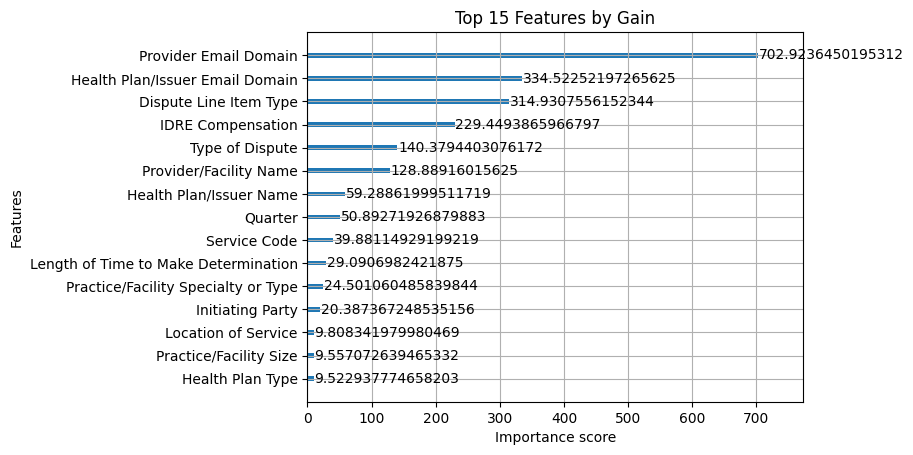

In [53]:
xgb.plot_importance(refined_model, importance_type="gain", max_num_features=15)
plt.title("Top 15 Features by Gain")
plt.show()

After excluding default decisions, the feature importance results have changed substantially. Provider Email Domain became the highest gain feature, followed by Health Plan/Issuer Email Domain and Dispute Line Item Type. Practice/Facility Size fell from the highest-gain feature in the initial model to 14th in the refined model, with its gain decreasing from approximately 1,918 to 9.55. This substantial reduction suggests that much of the predictive signal associated with Practice/Facility Size in the initial model was related to the default-decision population.

### 10. Investigating Provider Email Domain

Investigate Provider Email Domain as the dominant feature and assess whether it captures meaningful organizational patterns in arbitration outcomes.

#### 10.1 SHAP analysis

Use SHAP values to examine how individual provider email domains influence the model's predictions and the direction of those effects. Because gain identifies feature-level importance but does not show the direction of individual feature contributions, SHAP values are used to examine how Provider Email Domain affects model predictions.

In [ ]:
# Calculate SHAP values for refined model
dtrain_shap = xgb.DMatrix(data=feature_train, enable_categorical=True)

explainer = shap.TreeExplainer(refined_model)

shap_values = explainer.shap_values(dtrain_shap)

# Prepare data for SHAP visualization
clean_data = feature_train.copy()

for column in clean_data.columns:
    if (clean_data[column].dtype == "object" or str(clean_data[column].dtype) == "category"):
        clean_data[column] = clean_data[column].astype("string").fillna("Unknown")

shap_explanation = shap.Explanation(values=shap_values,
                                    data=clean_data.to_numpy(),
                                    feature_names=clean_data.columns.tolist() )

provider_email_shap = pd.DataFrame({ "provider_email_domain": clean_data["Provider Email Domain"].values,
                                     "shap_value": shap_values[:, clean_data.columns.get_loc("Provider Email Domain")] })

provider_email_summary = (provider_email_shap.groupby("provider_email_domain")
                                             .agg(mean_shap=("shap_value", "mean"),
                                                  observation_count=("shap_value", "size")))

provider_email_summary = (provider_email_summary[provider_email_summary["observation_count"] >= 10000].sort_values("mean_shap", ascending=False))

print("\nMost negative provider email domains:")
print(provider_email_summary.sort_values("mean_shap").head(5))

print("\nMost positive provider email domains:")
print(provider_email_summary.sort_values("mean_shap", ascending=False).head(5))

#### 10.2 Outcome Rates from the Original Data

Compare model-derived domain effects with observed arbitration outcome rates to determine whether the SHAP patterns correspond to actual differences in outcomes.

In [ ]:
provider_email_outcome_rates = ( pd.crosstab( refined_data['Provider Email Domain'],
                                              refined_data[target_column],
                                              normalize="index",
                                              dropna=False).mul(100).round(2) )
selected_domains = (provider_email_summary.sort_values("mean_shap").head(5).index.tolist() 
                     +
                    provider_email_summary.sort_values("mean_shap", ascending=False).head(5).index.tolist())

selected_domain_outcomes = (provider_email_outcome_rates.loc[provider_email_outcome_rates.index.isin(selected_domains)])

print("Outcome rates for selected provider email domains:")
print(selected_domain_outcomes)

Outcome rates for selected provider email domains:
Offer Selected from Provider or Issuer  In Favor of Plan/Issuer  \
Provider Email Domain                                             
bmhcc.org                                                 18.00   
envisionhealth.com                                        31.19   
halomd.com                                                15.92   
mbbrm.com                                                  1.61   
radpmg.com                                                 8.60   
saparm.com                                                 7.92   
scphealth.com                                             10.08   
specialtycare.net                                         14.21   
teamhealth.com                                             9.45   
totalcare.us                                              37.28   

Offer Selected from Provider or Issuer  In Favor of Provider/Facility/AA Provider  
Provider Email Domain                                       

The provider email domains identified by SHAP showed substantial differences in observed arbitration outcomes. Domains with the most negative mean SHAP values had lower provider/facility outcome rates, while domains with the most positive mean SHAP values had higher provider/facility outcome rates. For example, totalcare.us had a mean SHAP value of −1.29 and a provider/facility outcome rate of 62.72%, whereas mbbrm.com had a mean SHAP value of +0.81 and a provider/facility outcome rate of 98.39%. All domains included in this comparison had at least 10,000 observations, reducing the likelihood that the observed differences were driven by very small samples.

### 10.3 Combined Interpretation

Examine the organizations associated with high-impact domains to assess whether Provider Email Domain may be acting as a proxy for organizational or dispute-management characteristics.

Provider Email Domain captured organization-level information that was strongly associated with arbitration outcomes.

Public information indicates that several high-impact domains correspond to large physician-management organizations, provider groups, or organizations involved in IDR.

After default decisions were excluded, Provider Email Domain became the highest-gain feature in the refined model. SHAP analysis showed substantial differences in model contribution across domains, with some domains associated with predictions toward provider/facility outcomes and others associated with predictions toward plan/issuer outcomes. These patterns were also reflected in the observed arbitration outcomes.

Because an email domain identifies an organization rather than an intrinsic characteristic of the individual dispute, this raised the possibility that Provider Email Domain was functioning as a proxy for organizational characteristics or dispute representation practices. The analysis therefore examined the organizations associated with high-impact domains to better understand the source of the model's predictive signal.

Provider Email Domain may be functioning as a proxy for organizational identity and the organizational infrastructure through which disputes are submitted and managed.

In [71]:
selected_domain_table = (
    provider_email_summary
    .loc[selected_domains]
    .join(provider_email_outcome_rates)
    .sort_values("mean_shap")
)


print("Selected provider email domains:")
print(selected_domain_table)

Selected provider email domains:
                       mean_shap  observation_count  In Favor of Plan/Issuer  \
provider_email_domain                                                          
totalcare.us           -1.287527              34960                    37.28   
envisionhealth.com     -0.644491              40608                    31.19   
bmhcc.org              -0.319786              32594                    18.00   
halomd.com             -0.284937              58684                    15.92   
specialtycare.net      -0.276256              18985                    14.21   
radpmg.com              0.531441              22242                     8.60   
saparm.com              0.596767             181054                     7.92   
teamhealth.com          0.604803             137434                     9.45   
scphealth.com           0.643866              10363                    10.08   
mbbrm.com               0.806243              22454                     1.61   

      

### 10.4 Analysis of Stability Across Folds

Evaluate provider email domain effects across validation folds to determine whether the observed relationships remain consistent across different samples.

In [75]:
# Provider email domain stability across folds
provider_email_fold_results = []

for fold, (train_index, validation_index) in enumerate(cv.split(feature_train, target_train), 1):

    cv_feature_train = feature_train.iloc[train_index]
    cv_feature_validation = feature_train.iloc[validation_index]

    cv_target_train = target_train[train_index]
    cv_target_validation = target_train[validation_index]

    cv_dtrain = xgb.DMatrix(data=cv_feature_train,
                            label=cv_target_train,
                            enable_categorical=True)

    cv_dvalidation = xgb.DMatrix(data=cv_feature_validation,
                                 label=cv_target_validation,
                                 enable_categorical=True)

    cv_model = xgb.train(params=params,
                         dtrain=cv_dtrain,
                         num_boost_round=175,
                         evals=[(cv_dvalidation, "validation")],
                         verbose_eval=False)

    cv_explainer = shap.TreeExplainer(cv_model)

    cv_shap_values = cv_explainer.shap_values(cv_dvalidation)

    provider_email_index = cv_feature_validation.columns.get_loc("Provider Email Domain")

    cv_provider_email_shap = pd.DataFrame({"provider_email_domain": cv_feature_validation["Provider Email Domain"].astype("string").fillna("Unknown").values,
                                            "shap_value": (cv_shap_values[:, provider_email_index])})


    cv_provider_email_summary = (
        cv_provider_email_shap
        .groupby("provider_email_domain")
        .agg(mean_shap=("shap_value", "mean"),
             observation_count=("shap_value", "size")))
    cv_provider_email_summary["fold"] = fold
    provider_email_fold_results.append(cv_provider_email_summary.reset_index())
provider_email_fold_results = pd.concat(provider_email_fold_results, ignore_index=True)

In [ ]:
provider_email_fold_results_10k = (provider_email_fold_results[provider_email_fold_results["observation_count"] >= 10000])

print("Provider email domain SHAP results by fold:")
print(provider_email_fold_results_10k)

Provider email domain SHAP results by fold:
     provider_email_domain  mean_shap  observation_count  fold
7            agshealth.com   0.096789              13182     1
66      envisionhealth.com  -0.709698              10187     1
91              halomd.com  -0.283257              14730     1
208             saparm.com   0.555873              45387     1
223          sonoranrm.com   0.359070              10035     1
237         teamhealth.com   0.600708              34400     1
273          agshealth.com   0.148633              13478     2
330     envisionhealth.com  -0.677112              10070     2
358             halomd.com  -0.341516              14697     2
480             saparm.com   0.610952              45238     2
495          sonoranrm.com   0.394068              10028     2
510         teamhealth.com   0.599337              34652     2
547          agshealth.com   0.117004              13500     3
603     envisionhealth.com  -0.740154              10212     3
629        

The Provider Email Domain signal was stable across the four validation folds. Domains such as envisionhealth.com and halomd.com consistently produced negative mean SHAP values, while saparm.com and teamhealth.com consistently produced positive values. The direction of the association remained unchanged across folds, and the magnitude of the SHAP contributions was generally similar across validation samples. This suggests that the domain-level signal is not driven by a single subset of the data.

### 11. Findings from Model Refinement

The initial model identified Practice/Facility Size as the highest-gain feature. Further investigation showed that missing facility-size information was strongly associated with default decisions: 99.32% of disputes with an unknown Practice/Facility Size were default decisions. After excluding default decisions and retraining the model, Practice/Facility Size fell from the highest-gain feature to fourteenth, while Provider Email Domain became the highest-gain feature.

Further analysis showed substantial variation in Provider Email Domain effects. Domains with positive mean SHAP values generally had higher provider/facility outcome rates, while domains with negative mean SHAP values had lower provider/facility outcome rates. These patterns remained directionally consistent across validation folds, suggesting that the domain-level signal was not driven by a single subset of the data.

The results suggest that Provider Email Domain may function as a proxy for organizational identity or dispute-management structure rather than representing a direct characteristic of the underlying dispute. This interpretation warrants further investigation but illustrates how model interpretation and subject-matter analysis can identify potentially important sources of predictive signal that are not apparent from model performance metrics alone.

The refined model achieved a held-out test AUC of 0.8818, with a mean 4-fold cross-validation AUC of 0.8746 (SD = 0.0015). Although performance was lower than the initial model, the refined model retained substantial discriminatory ability and demonstrated stable performance across validation folds.